In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\ASUS\dev\projects\satellite-project-copy


In [2]:
import torch

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import matplotlib.pyplot as plt

from src.models.baseline_cnn import (
    BaselineCNN
)

In [3]:
PROJECT_ROOT = Path.cwd().parent

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "baseline_cnn_best.pt"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
)

CONFUSION_DIR = (
    OUTPUT_DIR
    / "confusion_matrices"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)

CONFUSION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [4]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


In [5]:
model = BaselineCNN()

model.load_state_dict(
    torch.load(
        CHECKPOINT_PATH,
        map_location=DEVICE
    )
)

model.to(DEVICE)

model.eval()

print("Checkpoint Loaded")

Checkpoint Loaded


In [6]:
class_names = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

In [7]:
label_map = {
    0:"AnnualCrop",
    1:"Forest",
    2:"HerbaceousVegetation",
    3:"Highway",
    4:"Industrial",
    5:"Pasture",
    6:"PermanentCrop",
    7:"Residential",
    8:"River",
    9:"SeaLake"
}

In [8]:
from torchvision import transforms
from torch.utils.data import DataLoader

from src.datasets.eurosat_dataset import EuroSATDataset

In [9]:
DATA_DIR = PROJECT_ROOT / "data"

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)

test_csv = (
    PROCESSED_DIR
    / "test_spatial.csv"
)

print(test_csv)

c:\Users\ASUS\dev\projects\satellite-project-copy\data\processed\test_spatial.csv


In [10]:
EUROSAT_MEAN = (
    0.34437724,
    0.38029198,
    0.40777111
)

EUROSAT_STD = (
    0.20265734,
    0.13689059,
    0.11554374
)

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        EUROSAT_MEAN,
        EUROSAT_STD
    )
])

In [11]:
test_dataset = EuroSATDataset(
    test_csv,
    transform=eval_transform
)

print(len(test_dataset))

2658


In [12]:
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(len(test_loader))

42


In [13]:
all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_preds = np.array(all_preds)

all_labels = np.array(all_labels)

print(len(all_preds))
print(len(all_labels))

2658
2658


In [14]:
accuracy = accuracy_score(
    all_labels,
    all_preds
)

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print(
    f"Test Accuracy: {accuracy:.4f}"
)

print(
    f"Macro F1: {macro_f1:.4f}"
)

Test Accuracy: 0.4654
Macro F1: 0.4998


In [15]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df

,precision,recall,f1-score,support
AnnualCrop,0.387597,0.909091,0.543478,275.000000
Forest,0.931034,0.257143,0.402985,105.000000
HerbaceousVegetation,0.723810,0.107496,0.187192,707.000000
Highway,0.515625,0.248120,0.335025,399.000000
Industrial,0.767857,0.704918,0.735043,244.000000
Pasture,0.162162,0.818182,0.270677,22.000000
PermanentCrop,0.273893,0.505376,0.355253,465.000000
Residential,0.706395,0.983806,0.822335,247.000000
River,0.508197,0.289720,0.369048,107.000000
SeaLake,0.966292,0.988506,0.977273,87.000000


In [16]:
report_path = (
    FIGURE_DIR
    / "baseline_cnn_classification_report.csv"
)

report_df.to_csv(
    report_path
)

print(report_path)

c:\Users\ASUS\dev\projects\satellite-project-copy\outputs\figures\baseline_cnn_classification_report.csv


In [17]:
per_class_f1 = report_df[
    ["f1-score"]
].iloc[:10]

per_class_f1

,f1-score
AnnualCrop,0.543478
Forest,0.402985
HerbaceousVegetation,0.187192
Highway,0.335025
Industrial,0.735043
Pasture,0.270677
PermanentCrop,0.355253
Residential,0.822335
River,0.369048
SeaLake,0.977273


In [18]:
f1_path = (
    FIGURE_DIR
    / "baseline_cnn_per_class_f1.csv"
)

per_class_f1.to_csv(
    f1_path
)

print(f1_path)

c:\Users\ASUS\dev\projects\satellite-project-copy\outputs\figures\baseline_cnn_per_class_f1.csv


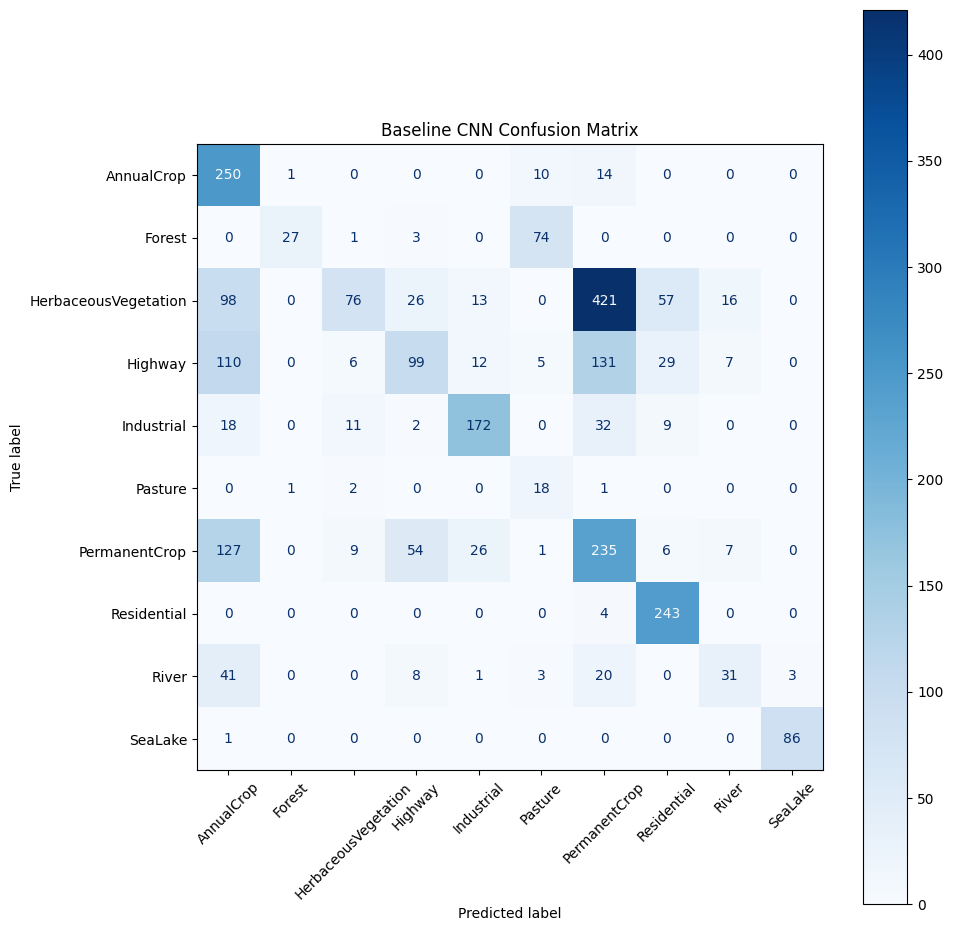

In [19]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

fig, ax = plt.subplots(
    figsize=(10,10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title(
    "Baseline CNN Confusion Matrix"
)

plt.tight_layout()

In [20]:
cm_path = (
    CONFUSION_DIR
    / "baseline_cnn_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(cm_path)

<Figure size 640x480 with 0 Axes>

c:\Users\ASUS\dev\projects\satellite-project-copy\outputs\confusion_matrices\baseline_cnn_confusion_matrix.png


In [21]:
summary = pd.DataFrame(
    {
        "Metric":[
            "Accuracy",
            "Macro_F1"
        ],
        "Value":[
            accuracy,
            macro_f1
        ]
    }
)

summary_path = (
    FIGURE_DIR
    / "baseline_cnn_summary_metrics.csv"
)

summary.to_csv(
    summary_path,
    index=False
)

summary

,Metric,Value
0,Accuracy,0.465388
1,Macro_F1,0.499831


In [22]:
train_df = pd.read_csv(
    PROCESSED_DIR / "train_spatial.csv"
)

val_df = pd.read_csv(
    PROCESSED_DIR / "val_spatial.csv"
)

test_df = pd.read_csv(
    PROCESSED_DIR / "test_spatial.csv"
)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

combined_df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

combined_df.shape

(27000, 8)

In [23]:
split_table = pd.crosstab(
    combined_df["split"],
    combined_df["class_name"]
)

split_table

class_name,AnnualCrop,Forest,HerbaceousVegetation,Highway,Industrial,Pasture,PermanentCrop,Residential,River,SeaLake
split,,,,,,,,,,
test,275,105,707,399,244,22,465,247,107,87
train,2443,2465,1481,2031,2094,1936,1731,2382,2323,2682
val,282,430,812,70,162,42,304,371,70,231


In [24]:
split_table.to_csv(
    PROCESSED_DIR
    / "split_class_distribution.csv"
)

In [25]:
combined_df["split"].value_counts()

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(21568, 8)
(2774, 8)
(2658, 8)
